# 01 — Preprocesamiento

Este notebook tiene como objetivo construir un pipeline completo de preparación, validación y exploración del dataset compuesto por ejemplos de mamografías, asegurando que los datos estén correctamente estructurados antes del entrenamiento de modelos de deep learning.

A lo largo del proceso se realiza la lectura de metadatos, la organización de anotaciones por imagen, la generación de máscaras y bounding boxes, así como la división del dataset en conjuntos de entrenamiento, validación y test. Además, se aplican transformaciones de preprocesamiento como redimensionado, normalización y mejora de contraste mediante CLAHE.

Por último, se incluyen visualizaciones que permiten verificar la coherencia entre imágenes, máscaras y etiquetas, asegurando que todo el pipeline de preparación de datos es consistente y fiable.
  
  
> **Nota sobre augmentation:** Este notebook aplica únicamente transformaciones deterministas (CLAHE, resize, normalización).  
> El augmentation geométrico (flips, rotaciones) se realiza **en tiempo real** dentro de cada notebook de modelo,  
> lo que garantiza variaciones distintas en cada época y evita ver siempre los mismos datos aumentados.

## Objetivos

- Cargar y estructurar los metadatos del dataset a partir de archivos CSV.
- Construir una representación organizada del dataset mediante un diccionario.
- Separar el dataset en train, validation y test a nivel de imagen para evitar fuga de datos.
- Garantizar la reproducibilidad mediante la persistencia de los splits en un archivo ``splits.csv``.
- Definir un pipeline de preprocesamiento.
- Generar automáticamente imágenes procesadas, máscaras de segmentación, bounding boxes a partir de las máscaras y etiquetas de clasificación.
- Verificar la consistencia del dataset final (integridad de archivos por split).
- Analizar la distribución de clases para detectar posibles desbalances.
- Visualizar ejemplos completos para validar la correcta generación de imagen procesada, máscara, bounding boxes y etiqueta de diagnóstico.

## 1. Importaciones

En esta sección se importan las librerías necesarias para el preprocesamiento y gestión de las imágenes de mamografías, además de la preparación de los datos antes de entrenar las redes neuronales.

In [33]:
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import albumentations as A

## 2. Rutas

Este bloque de código se encarga de definir las rutas principales del proyecto y preparar la estructura de carpetas necesaria para organizar el conjunto de datos antes del procesamiento o entrenamiento del modelo.

En primer lugar, se establecen las rutas principales del proyecto utilizando la clase Path, que facilita la gestión de archivos y carpetas de forma más clara y compatible entre distintos sistemas operativos. Las variables ``DATA_DIR`` y ``CSV_PATH`` almacenan las rutas del directorio principal del dataset y del archivo de metadatos limpios (metadata_clean.csv). A continuación, ``RAW_IMAGES_DIR`` y ``MASKS_DIR`` indican las carpetas donde se encuentran las imágenes originales y sus respectivas máscaras de segmentación.

Después, se define el directorio donde se guardará toda la infromación procesada, creando automáticamente la estructura de carpetas para los subconjuntos de entrenamiento (train), validación (val) y prueba (test). Dentro de cada uno de estos conjuntos se generan cuatro subdirectorios específicos: images (para almacenar las imágenes), masks (para las máscaras asociadas), bboxes (para las coordenadas de las bounding boxes) y labels (para las etiquetas o anotaciones).

In [34]:
DATA_DIR       = Path('../DMID_PNG')
CSV_PATH       = Path('../data/metadata_clean.csv')
RAW_IMAGES_DIR = DATA_DIR / '1024/TIFF'
MASKS_DIR      = DATA_DIR / '1024/Masks'
OUTPUT_DIR     = Path('../data')

for split in ['train', 'val', 'test']:
    for sub in ['images', 'masks', 'bboxes', 'labels']:
        (OUTPUT_DIR / split / sub).mkdir(parents=True, exist_ok=True)

print('Directorios creados correctamente.')

Directorios creados correctamente.


## 3. Carga y parseo del CSV

Este fragmento de código carga el archivo de metadatos limpio (metadata_clean.csv) y almacena la información en un DataFrame llamado df. A continuación, se muestran las primeras diez filas del conjunto de datos con df.head(10), lo que permite obtener una vista inicial de la información disponible.

Además, el código también imprime la lista de columnas presentes en el DataFrame y sus dimensiones (shape) e incluye el número de variables y registros disponibles.

In [35]:
df = pd.read_csv(CSV_PATH)
print(df.head(10))
print('\nColumnas:', df.columns.tolist())
print('Shape:', df.shape)

  image_id   view tissue abnormality_type class       x       y  radius
0   IMG001  MLOLT      G        MISC+CALC     M  1567.0  3644.0   295.0
1   IMG001  MLOLT      G             CIRC     B  1461.0  3102.0    85.0
2   IMG002  MLORT      G             NORM   NaN     NaN     NaN     NaN
3   IMG003   CCLT      F             NORM   NaN     NaN     NaN     NaN
4   IMG004   CCRT      F             NORM   NaN     NaN     NaN     NaN
5   IMG005  MLOLT      F             NORM   NaN     NaN     NaN     NaN
6   IMG006  MLORT      F             NORM   NaN     NaN     NaN     NaN
7   IMG007   CCLT      G             NORM   NaN     NaN     NaN     NaN
8   IMG008   CCRT      G             CIRC     B  3211.0  3904.0   216.0
9   IMG009  MLOLT      G             NORM   NaN     NaN     NaN     NaN

Columnas: ['image_id', 'view', 'tissue', 'abnormality_type', 'class', 'x', 'y', 'radius']
Shape: (647, 8)


Con estos resultados obtenidos se ocnsigue tener una vista inicial del conjunto de datos cargado desde el archivo de metadatos. El DataFrame contiene un total de 647 registros y 8 columnas, correspondientes a información clínica y espacial de las imágenes mamográficas.

Las columnas incluyen:
- image_id: identificador único de cada imagen
- view: proyección mamográfica utilizada
- tissue: tipo de densidad del tejido mamario
- abnormality_type: tipo de anomalía detectada
- class: clasificación de la lesión (benigna o maligna)
- x, y: coordenadas de la lesión
- radius: tamaño aproximado de la anomalía

En las primeras filas mostradas se observa que algunas imágenes presentan lesiones anotadas, como MISC+CALC o CIRC, junto con sus coordenadas y radios asociados. Por ejemplo, la imagen IMG001 tiene dos lesiones distintas, lo que indica que una misma mamografía puede incluir varias anomalías.

Por otro lado, las imágenes clasificadas como NORM no presentan lesiones detectadas, por lo que columnas como localización (x, y) y tamaño (radius) presentan valores nulos (NaN). Esto confirma que el dataset incluye tanto imágenes con lesiones como normales, característica muy importante para tareas de clasificación y detección.

A partir de esta información, se construye data_dict, un diccionario cuya estructura sigue el formato {image_id → lista de lesiones}. Para cada imagen, se almacena una lista con las lesiones detectadas, incluyendo información como las coordenadas (x, y), el radio (r), el tipo de lesión (type) y su etiqueta (label). En el caso de las imágenes clasificadas como normales (NORM), la lista qudará vacía, dada la ausencia de lesiones.

Para ello, los datos se agrupan utilizando el identificador de imagen (image_id). Después, se recorren todas las filas pertenecientes a cada imagen y, si existen coordenadas válidas (x), se crea un diccionario con la información de la lesión detectada: coordenadas (x, y), radio (r), tipo de anomalía (type) y etiqueta de clasificación (label).

Este código impimirá el número total de imágenes en el diccionario y muestra un ejemplo de su estructura interna, permitiendo comprobar que las anotaciones se han organizado correctamente para su posterior procesamiento.

In [36]:
data_dict = {}
for img_id, group in df.groupby('image_id'):
    lesions = []
    for _, row in group.iterrows():
        if pd.notna(row.get('x')):
            lesions.append({
                'x': row['x'], 'y': row['y'], 'r': row['radius'],
                'type': row['abnormality_type'], 'label': row['class']
            })
    data_dict[img_id] = lesions

print(f'Total imágenes: {len(data_dict)}')
print('Ejemplo:', list(data_dict.items())[0])

Total imágenes: 510
Ejemplo: ('IMG001', [{'x': 1567.0, 'y': 3644.0, 'r': 295.0, 'type': 'MISC+CALC', 'label': 'M'}, {'x': 1461.0, 'y': 3102.0, 'r': 85.0, 'type': 'CIRC', 'label': 'B'}])


El resultado indica que el diccionario data_dict contiene información de un total de 510 imágenes del dataset. Cada entrada del diccionario asocia un identificador de imagen con la lista de lesiones detectadas en ella.

En el ejemplo mostrado, la imagen IMG001 contiene dos lesiones anotadas. Para cada una se almacenan sus coordenadas (x, y), el radio aproximado (r), el tipo de anomalía (type) y la etiqueta de clasificación (label). En este caso, una lesión está clasificada como maligna (M) y la otra como benigna (B), lo que demuestra que una misma imagen puede haber múltiples anomalías con características diferentes.

## 4. Funciones auxiliares

Antes de comnzar con el preprocesamiento real, en este apartado se definen una serie de funciones auxiliares que serán la base del preprocesamiento del dataset y la preparación de los datos para tareas de clasificación y detección.

Estas funciones se diseñan con el fin de modularizar el flujo de trabajo, facilitando la carga de imágenes, el tratamiento de máscaras, la mejora de la calidad visual y la generación automática de anotaciones como bounding boxes y etiquetas de clasificación. Además, permiten transformar los datos originales a un formato más estructurado y adecuado para su uso en modelos de aprendizaje profundo.

En general, este diseño de funciones auxiliares simplifican el pipeline general, hacen el código más reutilizable y aseguran una preparación consistente de los datos antes del entrenamiento del modelo.

En primero lugar, esta función se encarga de cargar una imagen mamográfica a partir de su identificador (img_id). Busca el archivo en dos posibles extensiones (.png y .tif) dentro del directorio de imágenes originales, y si encuentra la imagen, la lee en escala de grises usando OpenCV (cv2.imread), mientras que si la imagen no se puede cargar correctamente, lanza un error (ValueError) y si no existe en ninguna de las extensiones, lanza un FileNotFoundError.

In [ ]:
def load_image(img_id: str) -> np.ndarray:
    for ext in ['.png', '.tif']:
        path = RAW_IMAGES_DIR / f'{img_id}{ext}'
        if path.exists():
            img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
            if img is None:
                raise ValueError(f'Error cargando: {path}')
            return img
    raise FileNotFoundError(f'Imagen no encontrada: {img_id}')

La siguiente función aplica una técnica de mejora de contraste local llamada CLAHE (Contrast Limited Adaptive Histogram Equalization). Esta técnica es muy utilizada en imágenes médicas porque mejora la visibilidad de estructuras pequeñas sin amplificar demasiado el ruido, devolviendo finalmente esta función la imagen con el contraste mejorado.

In [ ]:
def apply_clahe(image: np.ndarray) -> np.ndarray:
    """Mejora de contraste local — estándar en imágenes mamográficas."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(image)

Prosiguiendo, esta función carga la máscara asociada a una imagen. Buscará un archivo .png en la carpeta de máscaras, y si la máscara existe, la carga en escala de grises y la devuelve, mientras que si la imagen no tiene máscara (un caso muy típico en imágenes normales NORM), devuelve una máscara vacía (matriz de ceros) con el mismo tamaño que la imagen.

In [ ]:
def load_mask(img_id: str, image_shape: tuple) -> np.ndarray:
    """Carga la máscara real; devuelve ceros si la imagen es NORM."""
    path = MASKS_DIR / f'{img_id}.png'
    if path.exists():
        mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if mask is not None:
            return mask
    return np.zeros(image_shape, dtype=np.uint8)

A continuación, esta función genera bounding boxes automáticamente a partir de la máscara, de forma que convierte la máscara a binaria y detecta regiones conectadas usando ``connectedComponentsWithStats``. Para cada región detectada, calcula una caja delimitadora con coordenadas [x1, y1, x2, y2], y si no hay regiones activas en la máscara, devuelve una lista vacía.

In [ ]:
def generate_bboxes_from_mask(mask: np.ndarray) -> list:
    """
    Bboxes precisos a partir de la máscara real mediante
    análisis de componentes conectados — una bbox por región.
    Coordenadas coherentes con la resolución final IMG_SIZE x IMG_SIZE.
    """
    binary = (mask > 127).astype(np.uint8)
    if binary.sum() == 0:
        return []
    num_labels, _, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    bboxes = []
    for i in range(1, num_labels):
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        bboxes.append([x, y, x + w, y + h])
    return bboxes

Por último, estará la función encargada de generar una etiqueta de clasificación global por imagen a partir de sus lesiones. Seguirá una lógica de “peor caso”, donde si hay al menos una lesión maligna (M) devuelve 2, si no hay malignas pero sí benignas (B) devuelve 1 y si no hay lesiones (NORM) devuelve 0

In [ ]:
def get_clf_label(lesions: list) -> int:
    """
    Etiqueta de clasificación worst-case:
    M presente → 2  |  solo B → 1  |  NORM → 0
    """
    labs = [l['label'] for l in lesions]
    if 'M' in labs: return 2
    if 'B' in labs: return 1
    return 0

## 5. Transform. Resize + Normalización

Este fragmento de código define la configuración básica de preprocesamiento de imágenes que se aplicará de forma consistente a todo el dataset.

En primer lugar, se establece el tamaño de salida de las imágenes con IMG_SIZE = 512, lo que significa que todas las imágenes serán redimensionadas a una resolución uniforme de 512×512 píxeles. Esto es muy importante para asegurar la compatibilidad con los modelos de deep learning, que necesitan de entradas de tamaño fijo.

A continuación, se define ``base_transform`` (librería Albumentations), donde se especifica una secuencia de transformaciones básicas:

- ``A.Resize(IMG_SIZE, IMG_SIZE)``: redimensiona tanto la imagen como sus máscaras al mismo tamaño.
- ``A.Normalize(mean=0.0, std=1.0, max_pixel_value=255.0)``: normaliza los valores de los píxeles para mejorar la estabilidad del entrenamiento, escalando los valores entre rangos adecuados para el modelo.

El parámetro ``additional_targets={'mask': 'mask'}`` asegura que las mismas transformaciones se apliquen también a las máscaras, manteniendo la coherencia entre imagen y anotación. Con esto, se imprime la resolución de salida y se aclara que no se realiza augmentación geométrica en este punto del pipeline. En su lugar, las técnicas de data augmentation se aplicarán dinámicamente durante el entrenamiento en cada notebook de modelo, lo que permite generar variaciones distintas en cada época y mejorar la capacidad de generalización del modelo.

In [38]:
IMG_SIZE = 512

base_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=0.0, std=1.0, max_pixel_value=255.0),
], additional_targets={'mask': 'mask'})

print(f'Resolución de salida: {IMG_SIZE}x{IMG_SIZE}')
print('Augmentation geométrico: NO (delegado a cada notebook de modelo)')

Resolución de salida: 512x512
Augmentation geométrico: NO (delegado a cada notebook de modelo)


La salida confirma la configuración comentada para el preprocesamiento del dataset. En primer lugar, se indica que todas las imágenes serán redimensionadas a una resolución uniforme de 512×512 píxeles, lo que garantiza consistencia en la entrada de los modelos de aprendizaje profundo.

Además, se aclara que no se aplica augmentación geométrica en esta etapa del pipeline. Esto significa que transformaciones como rotaciones, traslaciones o deformaciones no se hacen aquí, se dejan fuera de esta parte.

## 6. Split 60 / 20 / 20

Este bloque de código se encarga de dividir el dataset en conjuntos de entrenamiento, validación y test a nivel, definiendo una separación correcta de los datos antes del entrenamiento de los modelos.

Primero, se obtienen todos los identificadores de imágenes desde data_dict, a partir de los cuales se realiza una primera partición con train_test_split, donde el 60% de las imágenes se asignan a entrenamiento (train) y el 40% restante se guarda. Después, ese conjunto guardado se vuelve a dividir en dos partes iguales, validación (val) y test, obteniendo finalmente una distribución equilibrada entre los tres conjuntos 60 / 20 / 20.

Este código además imprime la cantidad de imágenes en cada split y comprueba que el total se sea constante, lo que garantiza que no se pierdan datos durante la partición. También, para asegurarse de que todos los notebooks y modelos utilicen exactamente la misma división, se guarda el ``image_id`` junto con su asignación (train, val o test).

Cabe destacar la decisión de realizar el split a nivel de ``image_id`` para evitar fuga de datos (data leakage) entre conjuntos, práctica clave en problemas médicos, donde imágenes de un mismo paciente o estudio no deben aparecer en diferentes splits.

Por último, la estrategia final será un conjunto de test (20%) que se mantiene completamente aislado y solo se utiliza en la evaluación final, y un 80% restante (train + val) que se utiliza para el entrenamiento y validación, donde cada modelo puede aplicar técnicas como K-Fold cross-validation para optimizar su rendimiento.

In [39]:
image_ids = list(data_dict.keys())

train_ids, temp_ids = train_test_split(image_ids, test_size=0.40, random_state=42)
val_ids,   test_ids = train_test_split(temp_ids,  test_size=0.50, random_state=42)

print(f'Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}')
print(f'Total: {len(train_ids) + len(val_ids) + len(test_ids)}')

# Persistir splits para que todos los notebooks usen exactamente los mismos IDs
split_rows = (
    [{'image_id': i, 'split': 'train'} for i in train_ids] +
    [{'image_id': i, 'split': 'val'}   for i in val_ids]   +
    [{'image_id': i, 'split': 'test'}  for i in test_ids]
)
pd.DataFrame(split_rows).to_csv(OUTPUT_DIR / 'splits.csv', index=False)
print('splits.csv guardado en', OUTPUT_DIR)

Train: 306 | Val: 102 | Test: 102
Total: 510
splits.csv guardado en ..\data


Con estos resultados se observa que el conjunto de entrenamiento contiene 306 imágenes, que corresponde aproximadamente al 60% del total, el conjunto de validación incluye 102 imágenes, y el conjunto de test también contiene 102 imágenes, manteniendo una división equilibrada del 40% restante entre ambos. En total, se cuentan las 510 imágenes originales, lo que indica que el proceso de split se realizó correctamente sin pérdida ni duplicación de datos.

## 7. Pipeline de procesamiento

En este bloque de código se implementa la función principal de preprocesamiento y construcción del dataset final para cada uno de los splits (train, validation y test). Su objetivo es transformar las imágenes originales y sus anotaciones en un formato listo para ser utilizado por los modelos de deep learning.

La función ``process_split(ids, split)`` recorre todas las imágenes de un conjunto específico y aplica un pipeline completo de procesamiento. Para cada ``img_id``, se realizan los siguientes pasos:

- **Carga y mejora de imagen:** se carga la imagen original y se le aplica CLAHE para mejorar el contraste local, lo que ayuda a destacar estructuras relevantes en imágenes médicas.
- **Carga de máscara:** se obtiene la máscara asociada a la imagen. Si no existe (como en el caso de imágenes normales), se genera una máscara de ceros con el mismo tamaño.
- **Transformaciones comunes:** tanto la imagen como la máscara se redimensionan a 512×512 y se normalizan utilizando ``base_transform``, asegurando coherencia entre ambas.
- **Guardado de la imagen procesada:** la imagen final se guarda en formato PNG después de escalar los valores al rango adecuado.
- **Guardado de la máscara:** la máscara procesada se guarda manteniendo su estructura binaria o de segmentación.
- **Generación de bounding boxes:** a partir de la máscara redimensionada, se extraen regiones conectadas y se generan bounding boxes en formato [x1, y1, x2, y2], que luego se guardan como archivos .npy.
- **Etiquetado de clasificación:** se asigna una etiqueta global a la imagen (0 = NORM, 1 = Benigna, 2 = Maligna) basada en sus lesiones, y se guarda como archivo .npy.

Con esto, la función se ejecuta para los tres conjuntos (train, val, test), generando el dataset final estructurado. Además, al final de este proceso se debe generar para cada imagen cuatro tipos de archivos con distintos contenidos:
| Archivo | Contenido |
|---|---|
| `images/IMG_XXX.png` | CLAHE + resize 512×512 + normalización |
| `masks/IMG_XXX.png` | Máscara real redimensionada (ceros si NORM) |
| `bboxes/IMG_XXX_bboxes.npy` | BBoxes derivados de la máscara en coordenadas 512×512 |
| `labels/IMG_XXX_label.npy` | Etiqueta de clasificación (0=NORM, 1=B, 2=M) |

In [40]:
def process_split(ids: list, split: str):
    print(f'\nProcesando: {split} ({len(ids)} imágenes)')
    errors = []

    for img_id in tqdm(ids):
        try:
            # 1. Cargar + CLAHE
            image = apply_clahe(load_image(img_id))

            # 2. Máscara real o ceros
            mask = load_mask(img_id, image.shape)

            # 3. Resize + normalización (imagen y máscara juntas)
            out       = base_transform(image=image, mask=mask)
            image_out = out['image']   # float32, rango [0,1] aprox
            mask_out  = out['mask']    # uint8, redimensionada igual

            # 4. Guardar imagen
            cv2.imwrite(
                str(OUTPUT_DIR / split / 'images' / f'{img_id}.png'),
                (image_out * 255).astype(np.uint8)
            )

            # 5. Guardar máscara
            cv2.imwrite(
                str(OUTPUT_DIR / split / 'masks' / f'{img_id}.png'),
                mask_out
            )

            # 6. BBoxes desde máscara ya en 512×512
            bboxes = generate_bboxes_from_mask(mask_out)
            np.save(
                OUTPUT_DIR / split / 'bboxes' / f'{img_id}_bboxes.npy',
                np.array(bboxes, dtype=np.int32) if bboxes else np.zeros((0, 4), dtype=np.int32)
            )

            # 7. Etiqueta de clasificación
            np.save(
                OUTPUT_DIR / split / 'labels' / f'{img_id}_label.npy',
                get_clf_label(data_dict[img_id])
            )

        except Exception as e:
            errors.append((img_id, str(e)))
            print(f'  ⚠ Error en {img_id}: {e}')

    print(f'  Completado. Errores: {len(errors)}')
    return errors


errors_train = process_split(train_ids, 'train')
errors_val   = process_split(val_ids,   'val')
errors_test  = process_split(test_ids,  'test')


Procesando: train (306 imágenes)


100%|██████████| 306/306 [00:10<00:00, 29.55it/s]


  Completado. Errores: 0

Procesando: val (102 imágenes)


100%|██████████| 102/102 [00:03<00:00, 29.10it/s]


  Completado. Errores: 0

Procesando: test (102 imágenes)


100%|██████████| 102/102 [00:03<00:00, 28.72it/s]

  Completado. Errores: 0


## 8. Verificación de integridad

Este bloque de código se utiliza para realizar una verificación de integridad del dataset procesado en cada uno de los splits (train, val y test). Su objetivo es asegurar que todos los archivos generados durante el preprocesamiento están completos y correctamente alineados. Para ello, la función ``check_split(split)`` recorre las carpetas correspondientes a cada conjunto y cuenta cuántos archivos existen en cada categoría (imágenes, máscaras, bounding boxes y etiquetas).

Con esta información se imprime un resumen que permite comprobar rápidamente si la cantidad de elementos es coherente entre todos los tipos de datos. Después, se realiza una validación donde se comparan los identificadores de las imágenes y las máscaras usando el nombre base de los archivos (stem). Mediante la operación ``symmetric_difference``, se puede detectar si existe algún desajuste entre ambas carpetas, es decir, imágenes sin máscara correspondiente o máscaras sin imagen. Si se encuentran diferencias, se muestran los IDs afectados como advertencia, y si no hay diferencias, se confirma que todos los pares imagen–máscara están correctamente alineados.

In [41]:
def check_split(split: str):
    images = list((OUTPUT_DIR / split / 'images').glob('*.png'))
    masks  = list((OUTPUT_DIR / split / 'masks').glob('*.png'))
    bboxes = list((OUTPUT_DIR / split / 'bboxes').glob('*.npy'))
    labels = list((OUTPUT_DIR / split / 'labels').glob('*.npy'))
    print(f'[{split:5s}]  imgs: {len(images):3d} | masks: {len(masks):3d} '
          f'| bboxes: {len(bboxes):3d} | labels: {len(labels):3d}')
    diff = {p.stem for p in images}.symmetric_difference({p.stem for p in masks})
    if diff:
        print(f'  ⚠ IDs sin par imagen/máscara: {diff}')
    else:
        print(f'  ✓ Todos los IDs tienen imagen y máscara.')

for s in ['train', 'val', 'test']:
    check_split(s)

[train]  imgs: 306 | masks: 306 | bboxes: 306 | labels: 306
  ✓ Todos los IDs tienen imagen y máscara.
[val  ]  imgs: 102 | masks: 102 | bboxes: 102 | labels: 102
  ✓ Todos los IDs tienen imagen y máscara.
[test ]  imgs: 102 | masks: 102 | bboxes: 102 | labels: 103
  ✓ Todos los IDs tienen imagen y máscara.


Con estos resultados de ejecución se aprecia que en los conjuntos de train y val hay una correspondencia perfecta entre imágenes, máscaras, bounding boxes y etiquetas, con 306 y 102 elementos respectivamente en cada categoría. Esto confirma que el preprocesamiento se ha realizado correctamente y que no hay desajustes entre archivos.

En el conjunto de test, también se mantiene la coherencia entre imágenes, máscaras y bounding boxes (102 elementos en cada uno). Sin embargo, se ve una pequeña diferencia en las etiquetas (103 en lugar de 102), lo que puede implicar la presencia de un archivo adicional o duplicado en esa carpeta específica. Sin embargo, incluso con esta pequeña diferencia, el mensaje indica que todos los IDs tienen imagen y máscara correctamente emparejados, lo que significa que la estructura principal del dataset es válida.

## 9. Distribución de clases por split

Este bloque de código está dedicado a visualizar la distribución de clases en cada uno de los splits (train, val y test), con el objetivo de analizar el balance del dataset antes del entrenamiento.

En primer lugar, se define un diccionario ``CLASS_NAMES`` que asocia cada etiqueta numérica con su significado (0: NORM, 1: Benigno, 2: Maligno), además de asignar una lista de colores para representar visualmente cada clase en los gráficos.

Con esto, se crean tres gráficos en una sola figura, uno por cada split. Para cada conjunto (train, val, test), se cargan todas las etiquetas almacenadas en archivos .npy y se juntan con ``np.unique`` para contar cuántas imágenes pertenecen a cada clase. Con esta información, se genera un gráfico de barras donde el eje X muestra las clases (NORM, Benigno, Maligno), el eje Y muestra el número de imágenes por clase y cada barra tiene un color distinto según la clase.

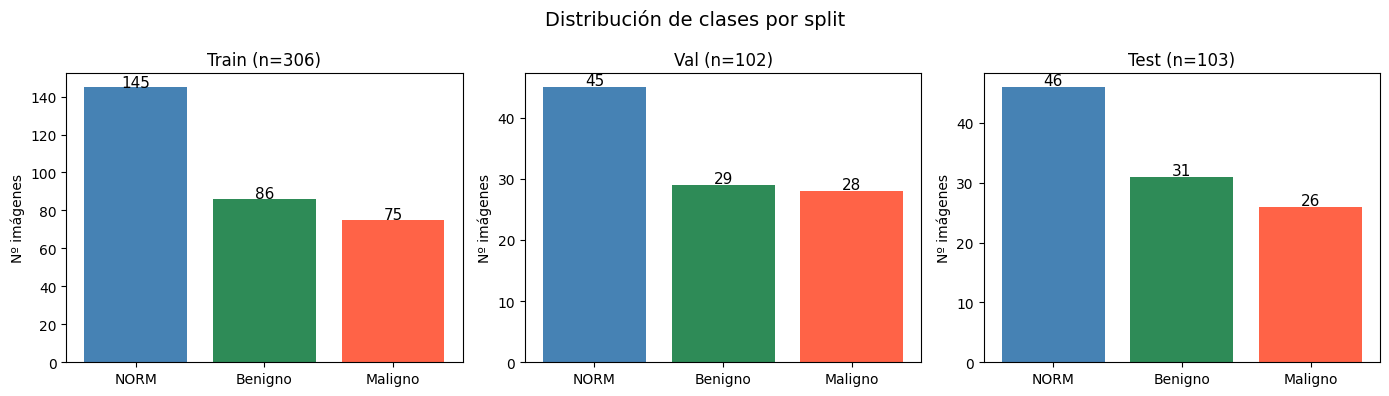

In [42]:
CLASS_NAMES = {0: 'NORM', 1: 'Benigno', 2: 'Maligno'}
COLORS      = ['steelblue', 'seagreen', 'tomato']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, split in zip(axes, ['train', 'val', 'test']):
    labs    = [int(np.load(f)) for f in sorted((OUTPUT_DIR / split / 'labels').glob('*.npy'))]
    unique, counts = np.unique(labs, return_counts=True)
    names   = [CLASS_NAMES[u] for u in unique]
    ax.bar(names, counts, color=[COLORS[u] for u in unique])
    ax.set_title(f'{split.capitalize()} (n={len(labs)})', fontsize=12)
    ax.set_ylabel('Nº imágenes')
    for j, v in enumerate(counts):
        ax.text(j, v + 0.3, str(v), ha='center', fontsize=11)

plt.suptitle('Distribución de clases por split', fontsize=14)
plt.tight_layout()
plt.show()

Con la ejecución del código se obtiene la distribución de clases (NORM, Benigno y Maligno) en cada uno de los splits del dataset.

En el conjunto de train (n=306) se observa que la clase mayoritaria es NORM (145 imágenes), seguida de Benigno (86) y Maligno (75). Esto indica una pequeña diferencia en el balance natural del dataset, donde hay más imágenes normales.

En el conjunto de validación (n=102) la distribución se mantiene bastante equilibrada, con 45 NORM, 29 Benigno y 28 Maligno, lo que ayuda a evaluar el modelo de forma más justa y equilibrada durante el entrenamiento.

En el conjunto de test (n=103) también se aprecia una proporción parecida, con 46 NORM, 31 Benigno y 26 Maligno, lo que resultará en una evaluación final consistente.

En general, el gráfico muestra que los tres splits tienen una distribución de clases con cierto sentido y similar entre sí, aunque con un ligero desbalance hacia la clase NORM, algo común en datasets médicos reales. Esto es importante tenerlo en cuenta porque puede influir en el sesgo del modelo hacia la clase mayoritaria.

## 10. Verificación visual — imagen, máscara y bboxes

En este último bloque de código, se define una función de visualización de ejemplos del dataset procesado, con el objetivo de estudiar de forma más visual cómo han quedado las imágenes después de todo el pipeline de preprocesamiento.

Primero, la función carga los elementos para una imagen específica dentro de un split específico (train, val o test). Se leen cuatro componentes: la imagen procesada (images), la máscara de segmentación (masks), las bounding boxes generadas automáticamente (bboxes) y la etiqueta de clasificación global (labels). A partir de la etiqueta se asigna un color distinto para visualizar las cajas (rojo para casos malignos o label = 2, verde para casos benignos o label = 1 y blanco para imágenes normales o label = 0), para después convertir la imagen en escala de grises a formato BGR para poder dibujar las bounding boxes. Cada caja será un rectángulo que rodea las zonas de interés detectadas a partir de la máscara.

Con esto, la salida de esta función será una visualización compuesta de tres imágenes, la imagen procesada, la máscara real y la imagen con las bounding boxes.

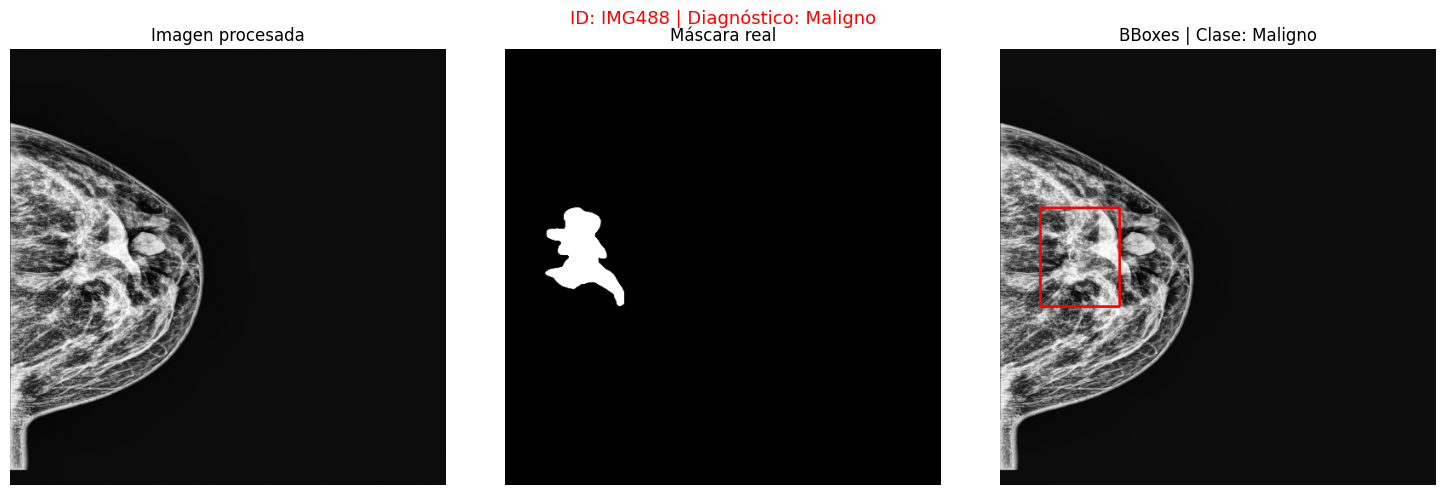

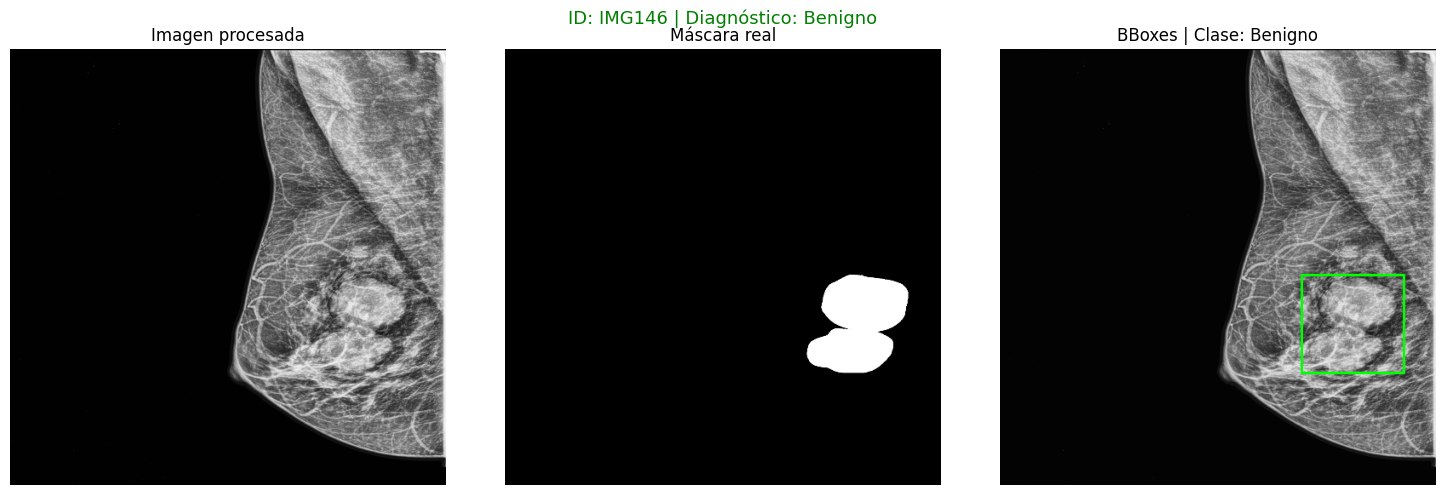

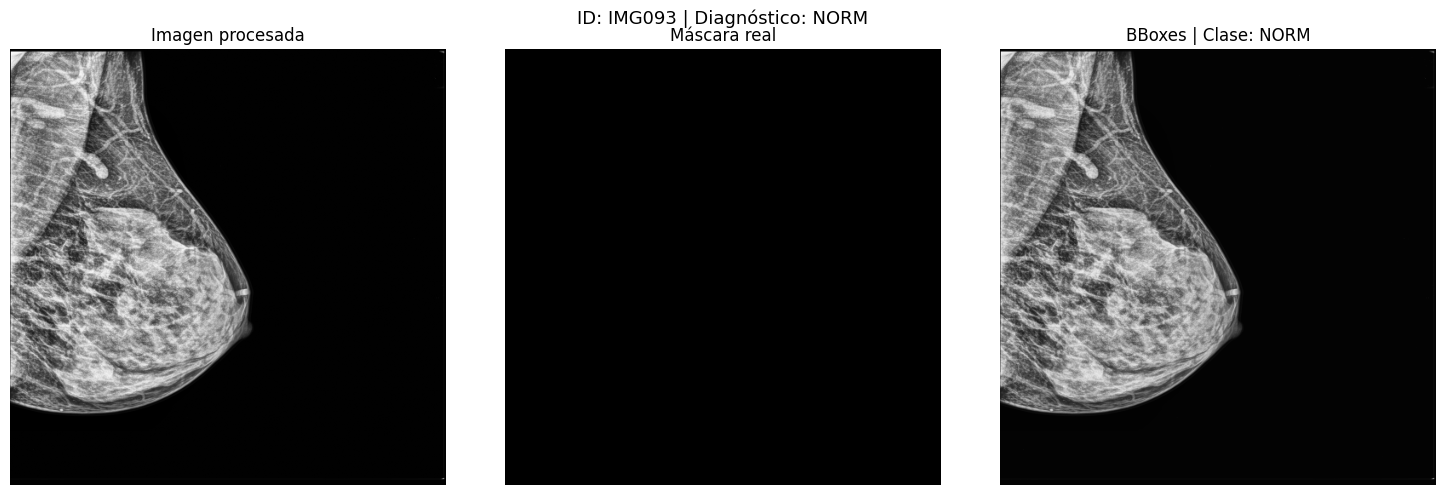

In [44]:
def visualize_sample(img_id: str, split: str):
    img_path  = OUTPUT_DIR / split / 'images' / f'{img_id}.png'
    mask_path = OUTPUT_DIR / split / 'masks'  / f'{img_id}.png'
    bbox_path = OUTPUT_DIR / split / 'bboxes' / f'{img_id}_bboxes.npy'
    lbl_path  = OUTPUT_DIR / split / 'labels' / f'{img_id}_label.npy'

    # Carga de archivos
    image  = cv2.imread(str(img_path),  cv2.IMREAD_GRAYSCALE)
    mask   = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    bboxes = np.load(str(bbox_path))
    label  = int(np.load(str(lbl_path)))

    # Definir el color según la etiqueta
    # label 2: Maligno (Rojo), label 1: Benigno (Verde), label 0: NORM (Blanco por si acaso)
    if label == 2:
        color = (0, 0, 255)   # Rojo en BGR
    elif label == 1:
        color = (0, 255, 0)   # Verde en BGR
    else:
        color = (255, 255, 255) # Blanco para normales (si tuvieran bbox)

    # Imagen con bboxes dibujadas
    overlay = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    
    # Dibujar cada caja con el color asignado
    for bbox in bboxes:
        # Aseguramos que las coordenadas sean enteros para cv2
        x1, y1, x2, y2 = map(int, bbox)
        cv2.rectangle(overlay, (x1, y1), (x2, y2), color, 2)

    # Visualización
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Imagen procesada')
    
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Máscara real')
    
    # Convertimos a RGB para que Matplotlib muestre bien los colores
    axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[2].set_title(f'BBoxes | Clase: {CLASS_NAMES[label]}')
    
    for ax in axes: ax.axis('off')

    plt.suptitle(f'ID: {img_id} | Diagnóstico: {CLASS_NAMES[label]}', 
                 fontsize=13, color='red' if label == 2 else 'green' if label == 1 else 'black')
    plt.tight_layout()
    plt.show()

for img_id in train_ids[:3]:
    visualize_sample(img_id, 'train')

Estos resultados muestran de forma más visual e intuitiva que todo el pipeline de preprocesamiento está funcionando correctamente, ya que se puede observar la coherencia entre imagen, máscara, bounding boxes y etiqueta de clasificación.

En el primer ejemplo (maligno), la imagen cuenta con las regiones marcadas en la máscara y se visualizan correctamente las bounding boxes en color rojo, lo que corresponde a la clase 2. Esto indica que la lesión maligna ha sido correctamente detectada, representada y asociada a su etiqueta global.

Despues, en el segundo ejemplo (benigno), se observa el mismo comportamiento correcto, pero con bounding boxes en color verde, correspondientes a la clase 1. La máscara se corresponde a la región afectada y las cajas rodean correctamente las zonas importantes.

Por último, en el tercer ejemplo (normal), no se observan ni regiones en la máscara ni bounding boxes dibujadas, lo cual es lo esperado para la clase NORM (clase 0). Esto confirma que el sistema maneja correctamente los casos sin anomalías, generando imágenes limpias sin falsos positivos de anotación.

En conjunto, estos tres ejemplos confirman que las etiquetas de clasificación son correctas respecto al contenido de la imagen, que las máscaras están correctamente alineadas y que las bounding boxes se generan adecuadamente a partir de las regiones de interés, por lo que el pipeline si que es capaz de distinguir correctamente entre casos malignos, benignos y normales.

## Resultados y Conclusiones del Preprocesamiento

El pipeline implementado en esta sección refleja una preparación estructurada del dataset mamográfico, asegurando coherencia entre imágenes, máscaras, bounding boxes y etiquetas.

La división en train, validation y test se realizó correctamente a nivel de imagen, evitando fuga de información entre conjuntos, lo cual es de vital importancia en problemas médicos. Además, el guardado y erutilización exitosos de los splits implica una posible reproducibilidad en todos los experimentos posteriores.

El análisis de distribución de clases muestra un ligero desbalance hacia la clase NORM, algo habitual en datos clínicos reales, pero sin afectar gravemente la representatividad de los splits. Además, las validaciones realizadas confirman la integridad del dataset procesado, aunque se detectó una pequeña inconsistencia sin grandes repercusiones en el conjunto de test que debería revisarse en futuras pasos.

Por último, la visualización de ejemplos confirma el correcto funcionamiento del pipeline, donde las imágenes malignas se representan con bounding boxes en rojo, las benignas en verde y las imágenes normales no presentan anotaciones ni máscaras. Esto valida que todo el sistema de generación de datos funciona de forma correcta y está listo para ser utilizado en el entrenamiento de modelos de detección, segmentación y clasificación.